In [23]:
import kagglehub
import pandas as pd
import numpy as np
import os

try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'))
    print(" Path to dataset files:", path)
    
except Exception as e:
    print(f"Something failed... {e}")

data.head()

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [24]:
data.columns = data.columns.str.strip()

print(data.shape)

print(data.dtypes)

(286467, 79)
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object


In [25]:
print(data.isnull().sum())
print('----')
print(data['Label'].value_counts())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64
----
Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64


In [26]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1',
    'Avg Fwd Segment Size',
    'Subflow fwd bytes',
    'Subflow fwd packets',
    'Subflow bwd Packets',
    'Subflow bwd bytes',
    'Packet Length Variance' 
]

data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25455
           1       1.00      1.00      1.00     31765

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
weighted avg       1.00      1.00      1.00     57220



Fwd Packet Length Max          0.108334
PSH Flag Count                 0.088424
Packet Length Mean             0.087658
Fwd Packet Length Mean         0.083266
Total Length of Fwd Packets    0.080835
Subflow Fwd Bytes              0.062280
Flow Duration                  0.050504
Total Fwd Packets              0.038251
Average Packet Size            0.037987
Bwd Packets/s                  0.034989
dtype: float64


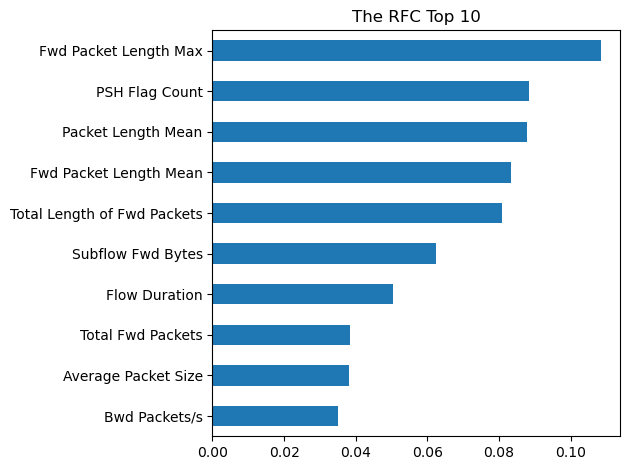

In [29]:
import matplotlib.pyplot as plt

rfc_importance = RandomForestClassifier(n_estimators = 100, random_state=1)
rfc_importance.fit(X,y)

importance = pd.Series(rfc_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).sort_values().plot(kind='barh')
plt.title('The RFC Top 10')
plt.tight_layout()
plt.show()